In [1]:
import preprocess as pp 
import calibration as cb 
import shortestpath as sp 
import pandas as pd 
import os

In [2]:
case = 'kochi' #use names in 'areas' dictionary

areas = {
    'ishinomaki': (38.4259826,141.3012349),  #2166925996
    'otaru' : (43.1908875, 140.9951859),  #1644237911
    'kochi' : (33.5581452, 133.5319937),  #5303394931
    'noto' : (37.3910308,136.9047961),  #11494769981
    'sumatra' : (5.5485879, 95.3137873),  #764419156
    'peru' : (-12.0716443,-77.1622644)  #3042136183
}

shelters = {'ishinomaki' : [2166925996],
            'otaru' : [1644237911],
            'kochi' : [5303394931],
            'noto' : [11494769981],
            'sumatra' : [764419156],
            'peru' : [3042136183]
}

pop = {'ishinomaki' : 3703,
         'otaru' : 5684,
         'kochi' : 2619,
         'noto' : 2507,
         'sumatra' : 3208,
         'peru' : 5105
    }

In [3]:
times_population = [1,5,10]
pp.main(areas=areas, foldername=case, evacnodes=shelters[case], times=times_population, pop=pop[case], multi=True, use_seed=False) 

rm: ./kochi: No such file or directory
rm: ./kochi_CAREFUL_PREVIOUS_INPUT: No such file or directory


Folder kochi created
Graph downloaded
Node 5303394931 is an evacuation node
Short links removed, nodes merged, counters updated, and link references adjusted successfully.


In [4]:
# Run Reinforcement Learning
maxnumSim = 0
numBlocks = 1
simPerBlock = 1000
simulTime = 30*60
meanrayleigh = 15

for t in times_population:
    numSim = 0
    maxnumSim = cb.run(foldername=case, 
                       numSim0=numSim,
                       maxnumSim=maxnumSim,
                       numBlocks=numBlocks, 
                       simPerBlock=simPerBlock, 
                       simulTime=simulTime, 
                       popfile=t,
                       meanrayleigh=meanrayleigh, 
                       reinforce_best_policy=False)
    print("="*10)
    print(maxnumSim)
    print("="*10)

There is a total of 2833 agents.


 ***** Simu 0 (t= 0.28)*****
epsilon greedy - exploration: 0.990000
survived pedestrians: 35


 ***** Simu 1 (t= 0.55)*****
epsilon greedy - exploration: 1.000000
survived pedestrians: 21


 ***** Simu 2 (t= 0.82)*****
epsilon greedy - exploration: 0.999001
survived pedestrians: 27


 ***** Simu 3 (t= 1.08)*****
epsilon greedy - exploration: 0.998004
survived pedestrians: 35


 ***** Simu 4 (t= 1.35)*****
epsilon greedy - exploration: 0.997009
survived pedestrians: 28


 ***** Simu 5 (t= 1.62)*****
epsilon greedy - exploration: 0.996016
survived pedestrians: 32


 ***** Simu 6 (t= 1.89)*****
epsilon greedy - exploration: 0.995025
survived pedestrians: 35


 ***** Simu 7 (t= 2.16)*****
epsilon greedy - exploration: 0.994036
survived pedestrians: 27


 ***** Simu 8 (t= 2.43)*****
epsilon greedy - exploration: 0.993049
survived pedestrians: 36


 ***** Simu 9 (t= 2.70)*****
epsilon greedy - exploration: 0.992063
survived pedestrians: 36


 ***** Simu 10 

survived pedestrians: 1694
survived pedestrians: 5784
survived pedestrians: 7768


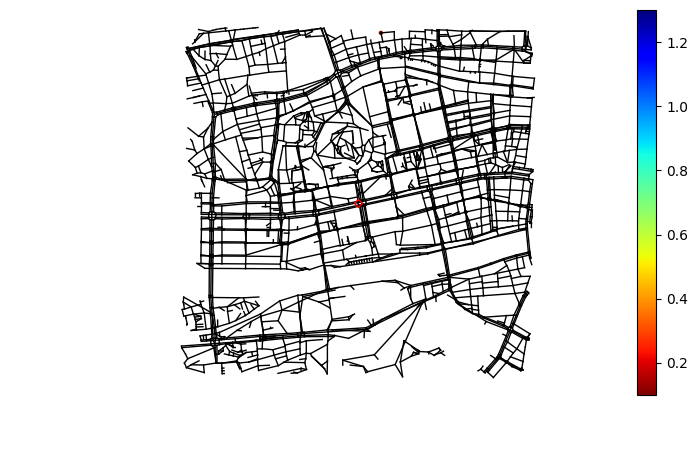

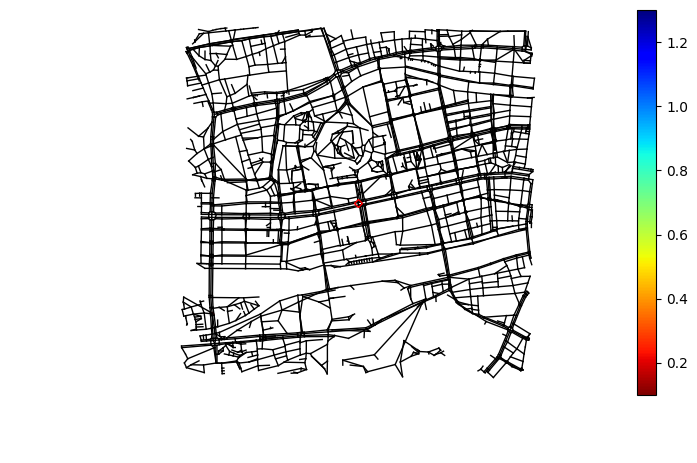

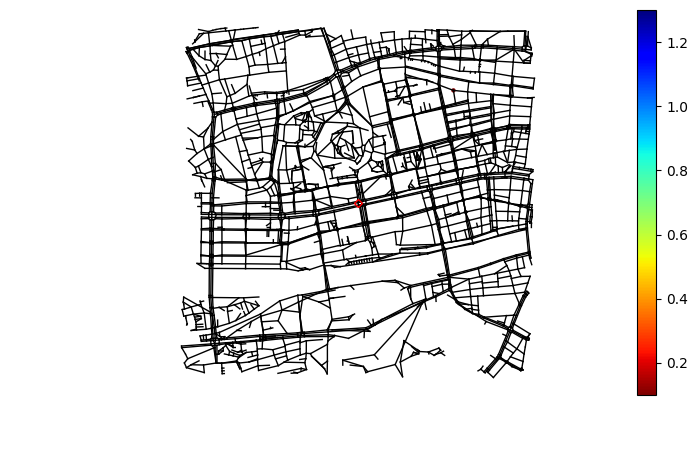

In [5]:
# Run Shortest Path
for t in times_population:
    sp.run(foldername=case, timeSimulation=simulTime, popfile=t, meanrayleigh=meanrayleigh)

In [6]:
rl_results = pd.read_csv(f'./{case}/StatesMatrices/survivorsPerSim.csv', names=['run','survivors'])
rl_results.head()

,run,survivors
0,0,354
1,1,308
2,2,336
3,3,304
4,4,349


In [7]:
rl_results['survivors'].max()

np.int64(6911)

In [8]:
mu = rl_results['survivors'].expanding().mean()
sd = rl_results['survivors'].expanding().std()
cv = sd / mu * 100

<Axes: >

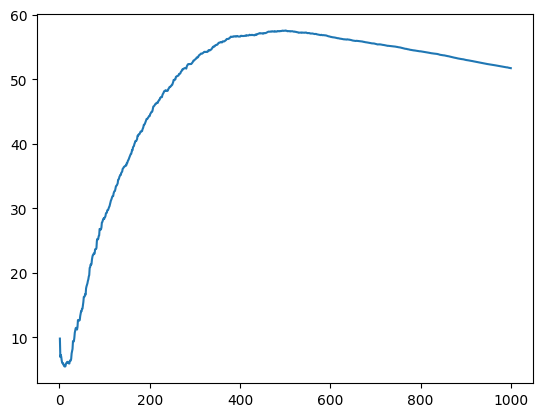

In [9]:
cv.plot()

# Some ideas - conclusions

- The GLEE factor might be the one making it converge always.
- We need to `calibrate` or `train` the model with:  
  (a) 1, 5, 10 agents per node  
  (b) Random real population number allocation => or MSS data  
  (c) Real population number based on census-mesh  
- Keep the same (optimal) `state matrix` of (a)-(c)